In [1]:
#!pip install UnityPy

In [2]:
import copy
import UnityPy

In [3]:
def first(env, type_name):
    for obj in env.objects:
        if obj.type.name == type_name:
            return obj, obj.parse_as_object()
    raise ValueError(f"No {type_name}")

## SOURCE ASSET

In [4]:
file_path_src = "../../data_db/cache/NDkyMDUzMDk2MDM5OA"
env_src = UnityPy.load(file_path_src)
assets = [{"name": asset.name, "target_platform": asset.target_platform.name} for asset in env_src.assets]
assets

[{'name': 'CustomAssetBundle-742e00342693e604f821865b00934430',
  'target_platform': 'StandaloneWindows'}]

In [5]:
src_tex_obj, src_tex = first(env_src, "Texture2D")
src_tex.m_Name

'elep001.CM'

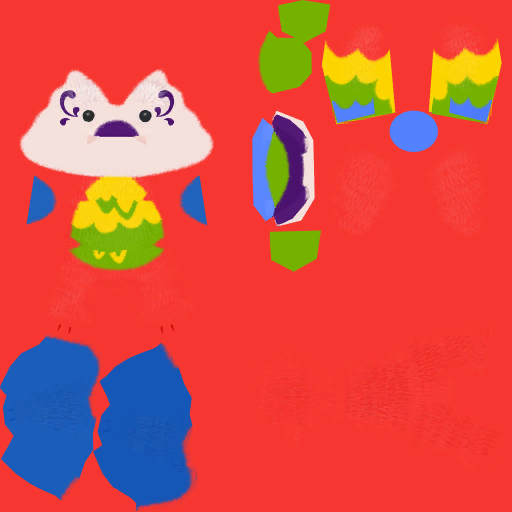

In [6]:
src_tex.image

In [7]:
src_mat_obj, src_mat = first(env_src, "Material")
src_mat

Material(m_Name='elep001.CM', m_SavedProperties=UnityPropertySheet(m_Colors=[(FastPropertyName(name='_Color'), ColorRGBA(r=1.0, g=1.0, b=1.0, a=1.0)), (FastPropertyName(name='_SpecColor'), ColorRGBA(r=0.2750000059604645, g=0.2750000059604645, b=0.19599999487400055, a=1.0)), (FastPropertyName(name='_RimColor'), ColorRGBA(r=0.2590000033378601, g=0.2590000033378601, b=0.23499999940395355, a=0.0))], m_Floats=[(FastPropertyName(name='_Shininess'), 0.10000000149011612), (FastPropertyName(name='_RimPower'), 2.5)], m_TexEnvs=[(FastPropertyName(name='_MainTex'), UnityTexEnv(m_Offset=Vector2f(0.0, 0.0), m_Scale=Vector2f(1.0, 1.0), m_Texture=PPtr(m_FileID=0, m_PathID=3, assetsfile=<SerializedFile>)))], m_Ints=None), m_Shader=PPtr(m_FileID=0, m_PathID=6, assetsfile=<SerializedFile>), disabledShaderPasses=None, m_BuildTextureStacks=None, m_CustomRenderQueue=None, m_DoubleSidedGI=None, m_EnableInstancingVariants=None, m_InvalidKeywords=None, m_LightmapFlags=None, m_ShaderKeywords=None, m_ValidKeywor

## DONOR ASSET

In [8]:
file_path_bear = "../../data_db/cache/OTQ0MDEwMDA4OTg3MA"
file_path_elep = "../../data_db/cache/OTQ0NjY5MzUzNTc1OA"
file_path_fdog = "../../data_db/cache/OTQ0Nzg1ODUwMzY5NA"
file_path_hams = "../../data_db/cache/OTQ0OTQ3MjI2MjE1OA"
file_path_kity = "../../data_db/cache/OTQ1MTg4NjA4NDExMA"
file_path_mnky = "../../data_db/cache/OTQ1MjM3NjgxNzY3OA"
file_path_pupy = "../../data_db/cache/OTQ1NDgwOTUxMzk5OA"
env_dst = UnityPy.load(file_path_elep)
assets = [{"name": asset.name, "target_platform": asset.target_platform.name} for asset in env_dst.assets]
assets

[{'name': 'CAB-elep002', 'target_platform': 'StandaloneWindows64'}]

In [9]:
dst_tex_obj, dst_tex = first(env_dst, "Texture2D")
dst_tex.m_Name

'elep002.CM'

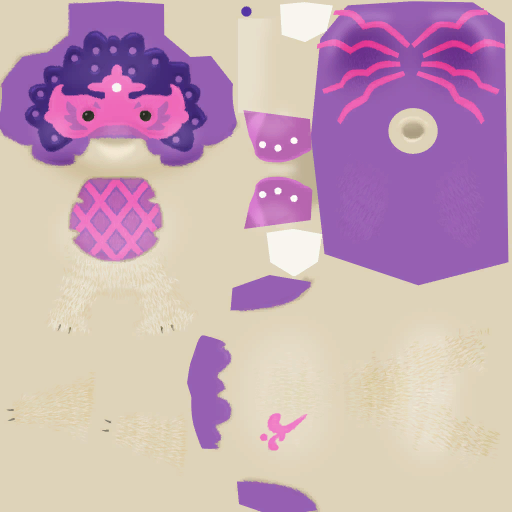

In [10]:
dst_tex.image

In [11]:
dst_mat_obj, dst_mat = first(env_dst, "Material")
dst_mat

Material(m_Name='elep002.cm', m_SavedProperties=UnityPropertySheet(m_Colors=[(FastPropertyName(name='_Color'), ColorRGBA(r=1.0, g=1.0, b=1.0, a=1.0)), (FastPropertyName(name='_RimColor'), ColorRGBA(r=0.2590000033378601, g=0.2590000033378601, b=0.23499999940395355, a=0.0)), (FastPropertyName(name='_SpecColor'), ColorRGBA(r=0.2750000059604645, g=0.2750000059604645, b=0.19599999487400055, a=1.0))], m_Floats=[(FastPropertyName(name='_RimPower'), 2.5), (FastPropertyName(name='_Shininess'), 0.10000000149011612)], m_TexEnvs=[(FastPropertyName(name='_MainTex'), UnityTexEnv(m_Offset=Vector2f(0.0, 0.0), m_Scale=Vector2f(1.0, 1.0), m_Texture=PPtr(m_FileID=0, m_PathID=1653592329973682742, assetsfile=<SerializedFile>)))], m_Ints=None), m_Shader=PPtr(m_FileID=2, m_PathID=7511548284335489480, assetsfile=<SerializedFile>), disabledShaderPasses=None, m_BuildTextureStacks=None, m_CustomRenderQueue=-1, m_DoubleSidedGI=None, m_EnableInstancingVariants=None, m_InvalidKeywords=None, m_LightmapFlags=5, m_Sha

## PATCH

In [12]:
dst_tex.image = src_tex.image
dst_tex.m_Name = src_tex.m_Name
dst_tex.save()

In [13]:
dst_mat.m_Name = src_mat.m_Name
# Copy simple material properties.
dst_mat.m_SavedProperties.m_Floats = copy.deepcopy(src_mat.m_SavedProperties.m_Floats)
dst_mat.m_SavedProperties.m_Colors = copy.deepcopy(src_mat.m_SavedProperties.m_Colors)
# Copy texture scale/offset, but keep target texture reference.
for i, (src_key, src_tex_env) in enumerate(src_mat.m_SavedProperties.m_TexEnvs):
    if i >= len(dst_mat.m_SavedProperties.m_TexEnvs):
        break
    dst_key, dst_tex_env = dst_mat.m_SavedProperties.m_TexEnvs[i]
    dst_tex_env.m_Scale = copy.deepcopy(src_tex_env.m_Scale)
    dst_tex_env.m_Offset = copy.deepcopy(src_tex_env.m_Offset)
dst_mat.save()

## OUTPUT

In [14]:
# destination asset file
file_path_out = '../../data_db/MTA5OTUxMTYyODk1MA'
with open(file_path_out, "wb") as f:
    f.write(env_dst.file.save())